# 🔍 EDA — Retail Churn Project
**Exploration notebook** — run this BEFORE preprocessing.py  
Goal: understand the data, find leaky columns, spot redundancy, guide feature engineering decisions.

---
### Sections
1. Load & basic info  
2. Target distribution (Churn)
3. **Correlation vector with Churn** ← leakage detection  
4. Feature-to-feature heatmap (redundancy detection)  
5. Distribution plots (numeric features)  
6. Churn rate by category (categorical features)  
7. Missing values analysis  
8. Outlier detection  
9. Temporal patterns (RegistrationDate)  
10. Country churn rates  
11. Key findings summary

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'figure.facecolor': 'white',
    'axes.facecolor'  : 'white',
})
PALETTE   = {'Fidèle': '#378ADD', 'Churn': '#E24B4A'}
C_CHURN   = '#E24B4A'
C_LOYAL   = '#378ADD'
C_NEUTRAL = '#888780'
print('✅ Imports ready')

✅ Imports ready


---
## 1. Load & basic info

In [9]:
df = pd.read_csv(r"D:\projet_ml_retail\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv")

print(f'Shape         : {df.shape}')
print(f'Columns       : {df.shape[1]}')
print(f'Rows          : {df.shape[0]:,}')
print(f'Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('── Dtypes ──────────────────────────')
print(df.dtypes.value_counts())
print()
print('── Head ────────────────────────────')
df.head(3)

Shape         : (4372, 52)
Columns       : 52
Rows          : 4,372
Memory usage  : 5.7 MB

── Dtypes ──────────────────────────
int64      20
object     18
float64    14
Name: count, dtype: int64

── Head ────────────────────────────


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0


In [10]:
# Quick summary statistics
df.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,4372.000000,nan,nan,nan,15299.677722,1722.390705,12346.000000,13812.750000,15300.500000,16778.250000,18287.000000
Recency,4372.000000,nan,nan,nan,92.047118,100.765435,1.000000,17.000000,50.000000,143.000000,374.000000
Frequency,4372.000000,nan,nan,nan,5.075480,9.338754,1.000000,1.000000,3.000000,5.000000,248.000000
MonetaryTotal,4372.000000,nan,nan,nan,1898.459701,8219.345141,-4287.630000,293.362500,648.075000,1611.725000,279489.020000
MonetaryAvg,4372.000000,nan,nan,nan,28.839013,127.323926,-4287.630000,10.985960,16.918616,23.542941,3861.000000
MonetaryStd,4372.000000,nan,nan,nan,88.672383,2689.001161,0.000000,6.226414,10.349780,20.629858,137554.852393
MonetaryMin,4372.000000,nan,nan,nan,-86.425754,2876.398935,-168469.600000,-11.500000,0.790000,6.960000,3861.000000
MonetaryMax,4372.000000,nan,nan,nan,185.179522,2881.283699,-4287.630000,31.800000,52.020000,102.000000,168469.600000
TotalQuantity,4372.000000,nan,nan,nan,1122.344007,4672.790720,-303.000000,153.000000,365.000000,962.250000,196719.000000
AvgQuantityPerTransaction,4372.000000,nan,nan,nan,22.389288,213.257466,-144.000000,5.475745,9.494392,14.008333,12540.000000


---
## 2. Target distribution — Churn

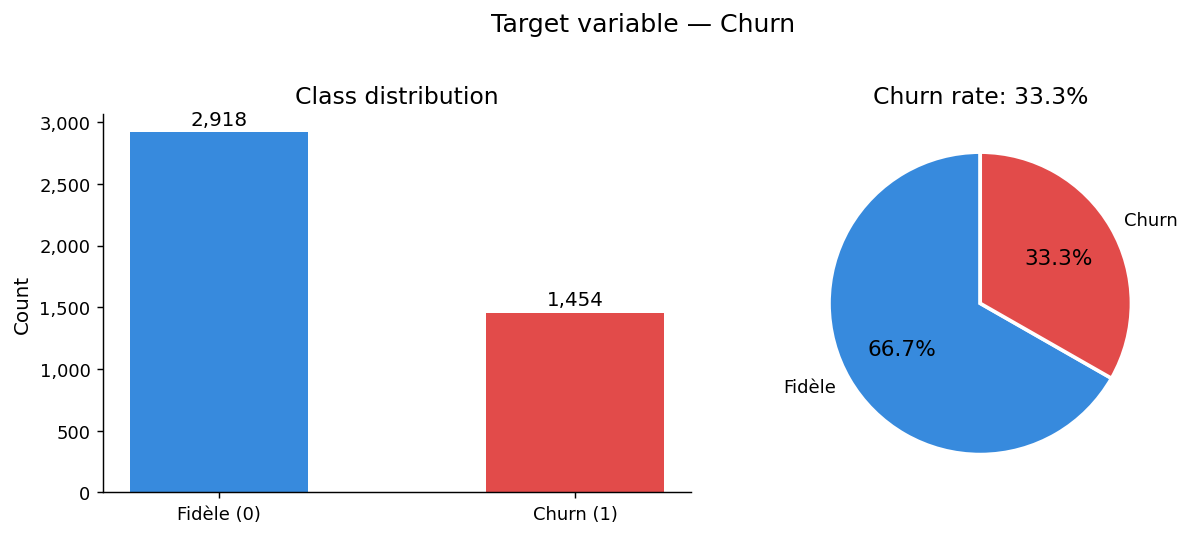


📊 Churn rate     : 33.26%
   Fidèle count   : 2,918
   Churn count    : 1,454
   Imbalance ratio: 2.0:1  → SMOTE will be needed in training


In [12]:
churn_counts = df['Churn'].value_counts()
churn_rate   = df['Churn'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = [C_LOYAL, C_CHURN]
bars = axes[0].bar(['Fidèle (0)', 'Churn (1)'], churn_counts.values,
                   color=colors, width=0.5, edgecolor='none')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='500')
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels=['Fidèle', 'Churn'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)
for t in autotexts: t.set_fontsize(12)
axes[1].set_title(f'Churn rate: {churn_rate:.1%}')

import os

os.makedirs('reports', exist_ok=True)

plt.savefig('reports/eda_01_target_distribution.png', bbox_inches='tight')

plt.suptitle('Target variable — Churn', fontsize=14, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig('reports/eda_01_target_distribution.png', bbox_inches='tight')
plt.show()

print(f'\n📊 Churn rate     : {churn_rate:.2%}')
print(f'   Fidèle count   : {churn_counts[0]:,}')
print(f'   Churn count    : {churn_counts[1]:,}')
imbalance = churn_counts.max() / churn_counts.min()
print(f'   Imbalance ratio: {imbalance:.1f}:1  → SMOTE will be needed in training')

---
## 3. Correlation vector with Churn ← LEAKAGE DETECTION
This is the key step. We compute the correlation of **every numeric feature with the Churn column**.
Any feature with |corr| > 0.5 is suspicious — it may be encoding the answer.

In [ ]:
# ── Compute correlation of every numeric feature with Churn ─────────────────
numeric_df   = df.select_dtypes(include=['int64','float64'])
churn_corr   = numeric_df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print('Top correlations with Churn (absolute value, descending):')
print('='*50)
for feat, val in churn_corr.items():
    bar   = '█' * int(abs(val) * 30)
    sign  = '+' if val >= 0 else '-'
    flag  = '  ⚠️  LEAKY — DROP' if abs(val) > 0.5 else ('  ⚡ Strong' if abs(val) > 0.3 else '')
    print(f'  {feat:<30} {sign}{abs(val):.3f}  {bar}{flag}')

Top correlations with Churn (absolute value, descending):
  Recency                        +0.859  █████████████████████████  ⚠️  LEAKY — DROP
  CustomerTenureDays             -0.453  █████████████  ⚡ Strong
  PreferredMonth                 -0.431  ████████████  ⚡ Strong
  UniqueDescriptions             -0.270  ████████
  UniqueProducts                 -0.270  ████████
  Frequency                      -0.223  ██████
  UniqueInvoices                 -0.223  ██████
  FirstPurchaseDaysAgo           +0.222  ██████
  TotalTransactions              -0.182  █████
  CancelledTransactions          -0.129  ███
  NegativeQuantityCount          -0.129  ███
  TotalQuantity                  -0.117  ███
  MonetaryTotal                  -0.114  ███
  AvgLinesPerInvoice             -0.105  ███
  ReturnRatio                    +0.094  ██
  AvgDaysBetweenPurchases        -0.053  █
  AvgProductsPerTransaction      -0.037  █
  ZeroPriceCount                 -0.032  
  Age                            -0.020 

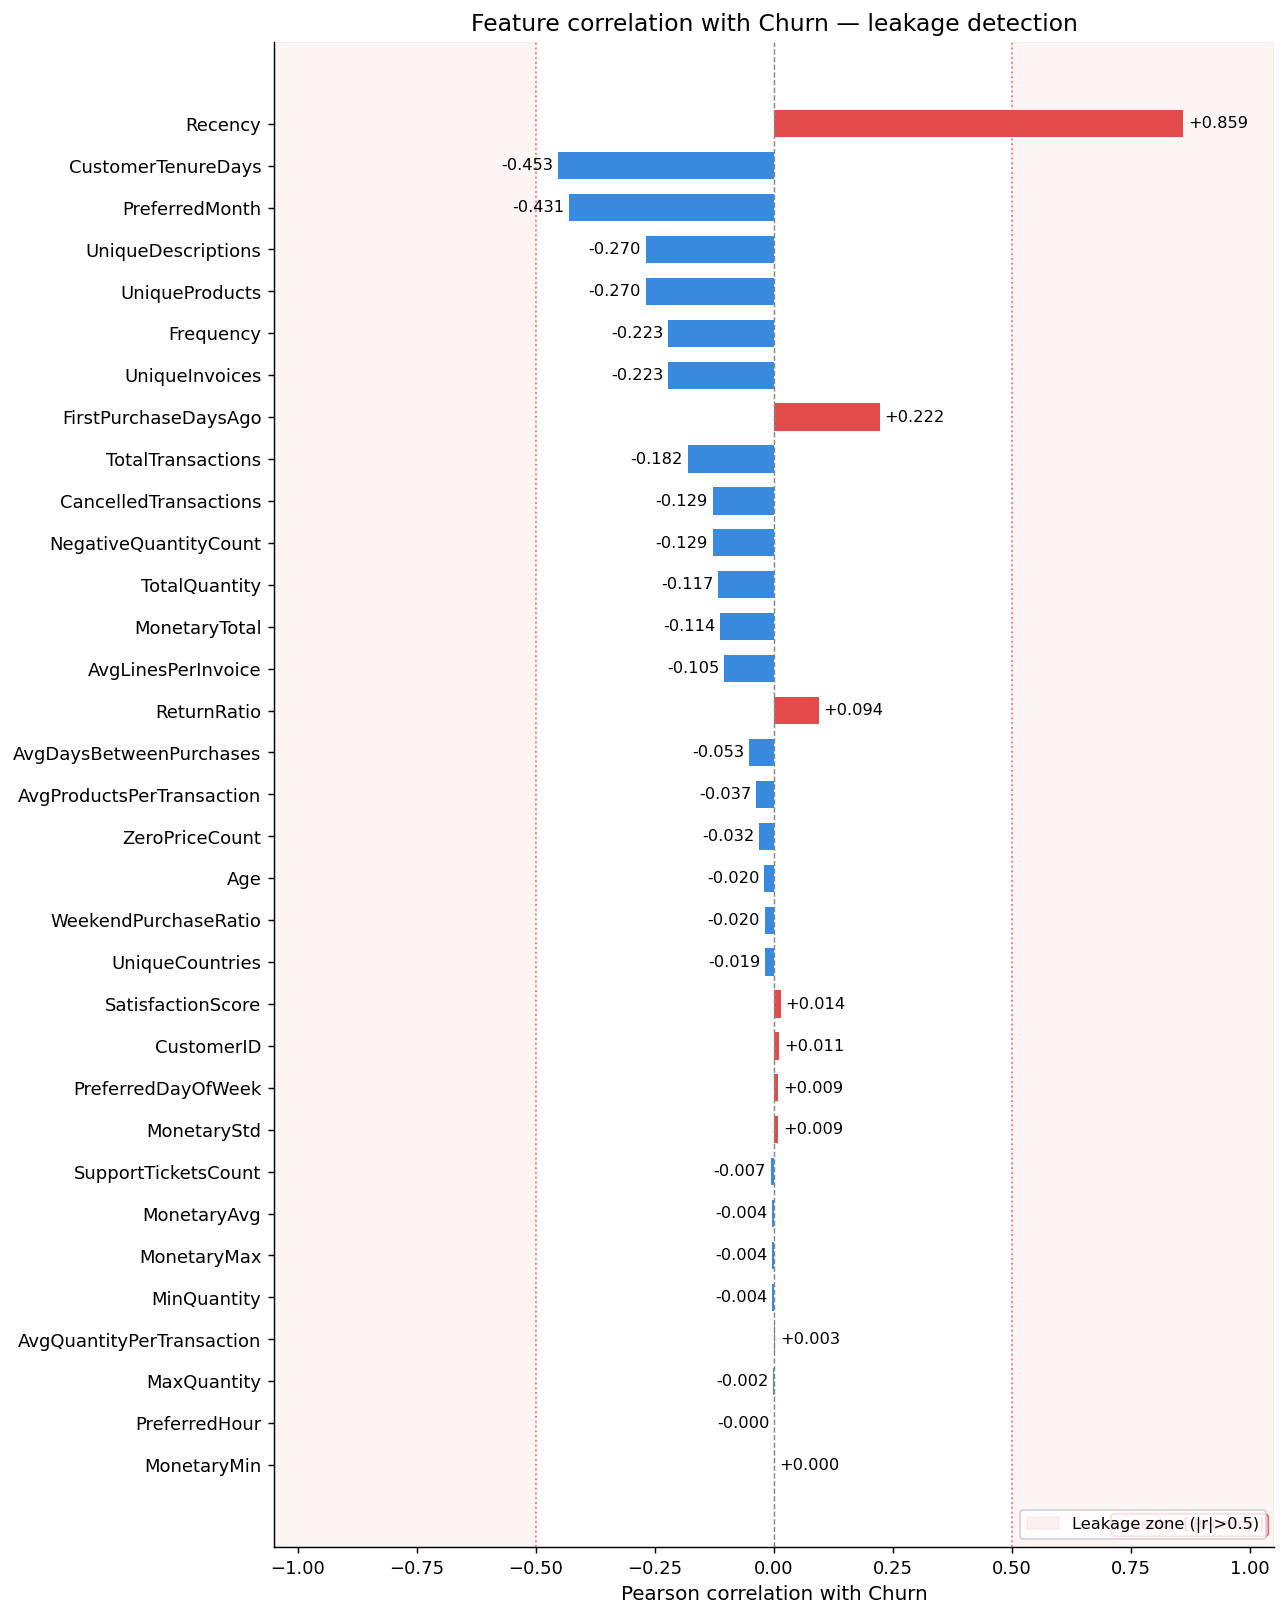


⚠️  Leaky features (|corr| > 0.5): ['Recency']
   → These should be dropped in preprocessing.py


In [13]:
# ── Visualize as horizontal bar chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, len(churn_corr)*0.38)))

colors_bar = [C_CHURN if v > 0 else C_LOYAL for v in churn_corr.values]
bars = ax.barh(churn_corr.index[::-1], churn_corr.values[::-1],
               color=colors_bar[::-1], edgecolor='none', height=0.65)

# Add value labels
for bar, val in zip(bars, churn_corr.values[::-1]):
    xpos = val + (0.01 if val >= 0 else -0.01)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

# Danger zone shading
ax.axvspan( 0.5,  1.05, alpha=0.06, color=C_CHURN, label='Leakage zone (|r|>0.5)')
ax.axvspan(-1.05,-0.5,  alpha=0.06, color=C_CHURN)
ax.axvline(0, color=C_NEUTRAL, linewidth=0.8, linestyle='--')
ax.axvline( 0.5, color=C_CHURN, linewidth=1, linestyle=':', alpha=0.7)
ax.axvline(-0.5, color=C_CHURN, linewidth=1, linestyle=':', alpha=0.7)

ax.set_xlabel('Pearson correlation with Churn')
ax.set_title('Feature correlation with Churn — leakage detection', fontweight='500')
ax.set_xlim(-1.05, 1.05)
ax.legend(loc='lower right', fontsize=9)

# Annotate leaky features
leaky = churn_corr[abs(churn_corr) > 0.5].index.tolist()
if leaky:
    ax.text(0.99, 0.01, f'⚠️ Leaky: {leaky}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color=C_CHURN,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FCEBEB', edgecolor=C_CHURN, alpha=0.8))

plt.tight_layout()
plt.savefig('reports/eda_02_churn_correlation_vector.png', bbox_inches='tight')
plt.show()

print(f'\n⚠️  Leaky features (|corr| > 0.5): {leaky}')
print('   → These should be dropped in preprocessing.py')

In [14]:
# ── Point-biserial correlation (more rigorous for binary target) ─────────────
# Pearson works but point-biserial is the statistically correct method
# when one variable is binary (Churn = 0/1)

print('Point-biserial correlation with Churn (+ p-value):')
print('='*60)

results = []
for col in numeric_df.columns:
    if col == 'Churn': continue
    clean = numeric_df[['Churn', col]].dropna()
    corr, pval = stats.pointbiserialr(clean['Churn'], clean[col])
    results.append({'Feature': col, 'Correlation': corr, 'p-value': pval,
                    'Significant': '✅' if pval < 0.05 else '❌',
                    'Flag': '⚠️ LEAKY' if abs(corr) > 0.5 else ('⚡ Strong' if abs(corr) > 0.3 else '')})

res_df = pd.DataFrame(results).sort_values('Correlation', key=abs, ascending=False)
res_df['Correlation'] = res_df['Correlation'].round(4)
res_df['p-value']     = res_df['p-value'].apply(lambda x: f'{x:.2e}')
res_df.style.background_gradient(cmap='RdBu_r', subset=['Correlation'], vmin=-1, vmax=1)

Point-biserial correlation with Churn (+ p-value):


,Feature,Correlation,p-value,Significant,Flag
1,Recency,0.859000,0.00e+00,✅,⚠️ LEAKY
12,CustomerTenureDays,-0.453500,9.65e-221,✅,⚡ Strong
16,PreferredMonth,-0.430900,3.14e-197,✅,⚡ Strong
20,UniqueDescriptions,-0.269800,8.17e-74,✅,
19,UniqueProducts,-0.269800,8.19e-74,✅,
2,Frequency,-0.222600,3.16e-50,✅,
28,UniqueInvoices,-0.222600,3.16e-50,✅,
13,FirstPurchaseDaysAgo,0.221600,8.85e-50,✅,
27,TotalTransactions,-0.181700,9.52e-34,✅,
25,CancelledTransactions,-0.129000,1.13e-17,✅,


---
## 4. Feature-to-feature heatmap — redundancy detection

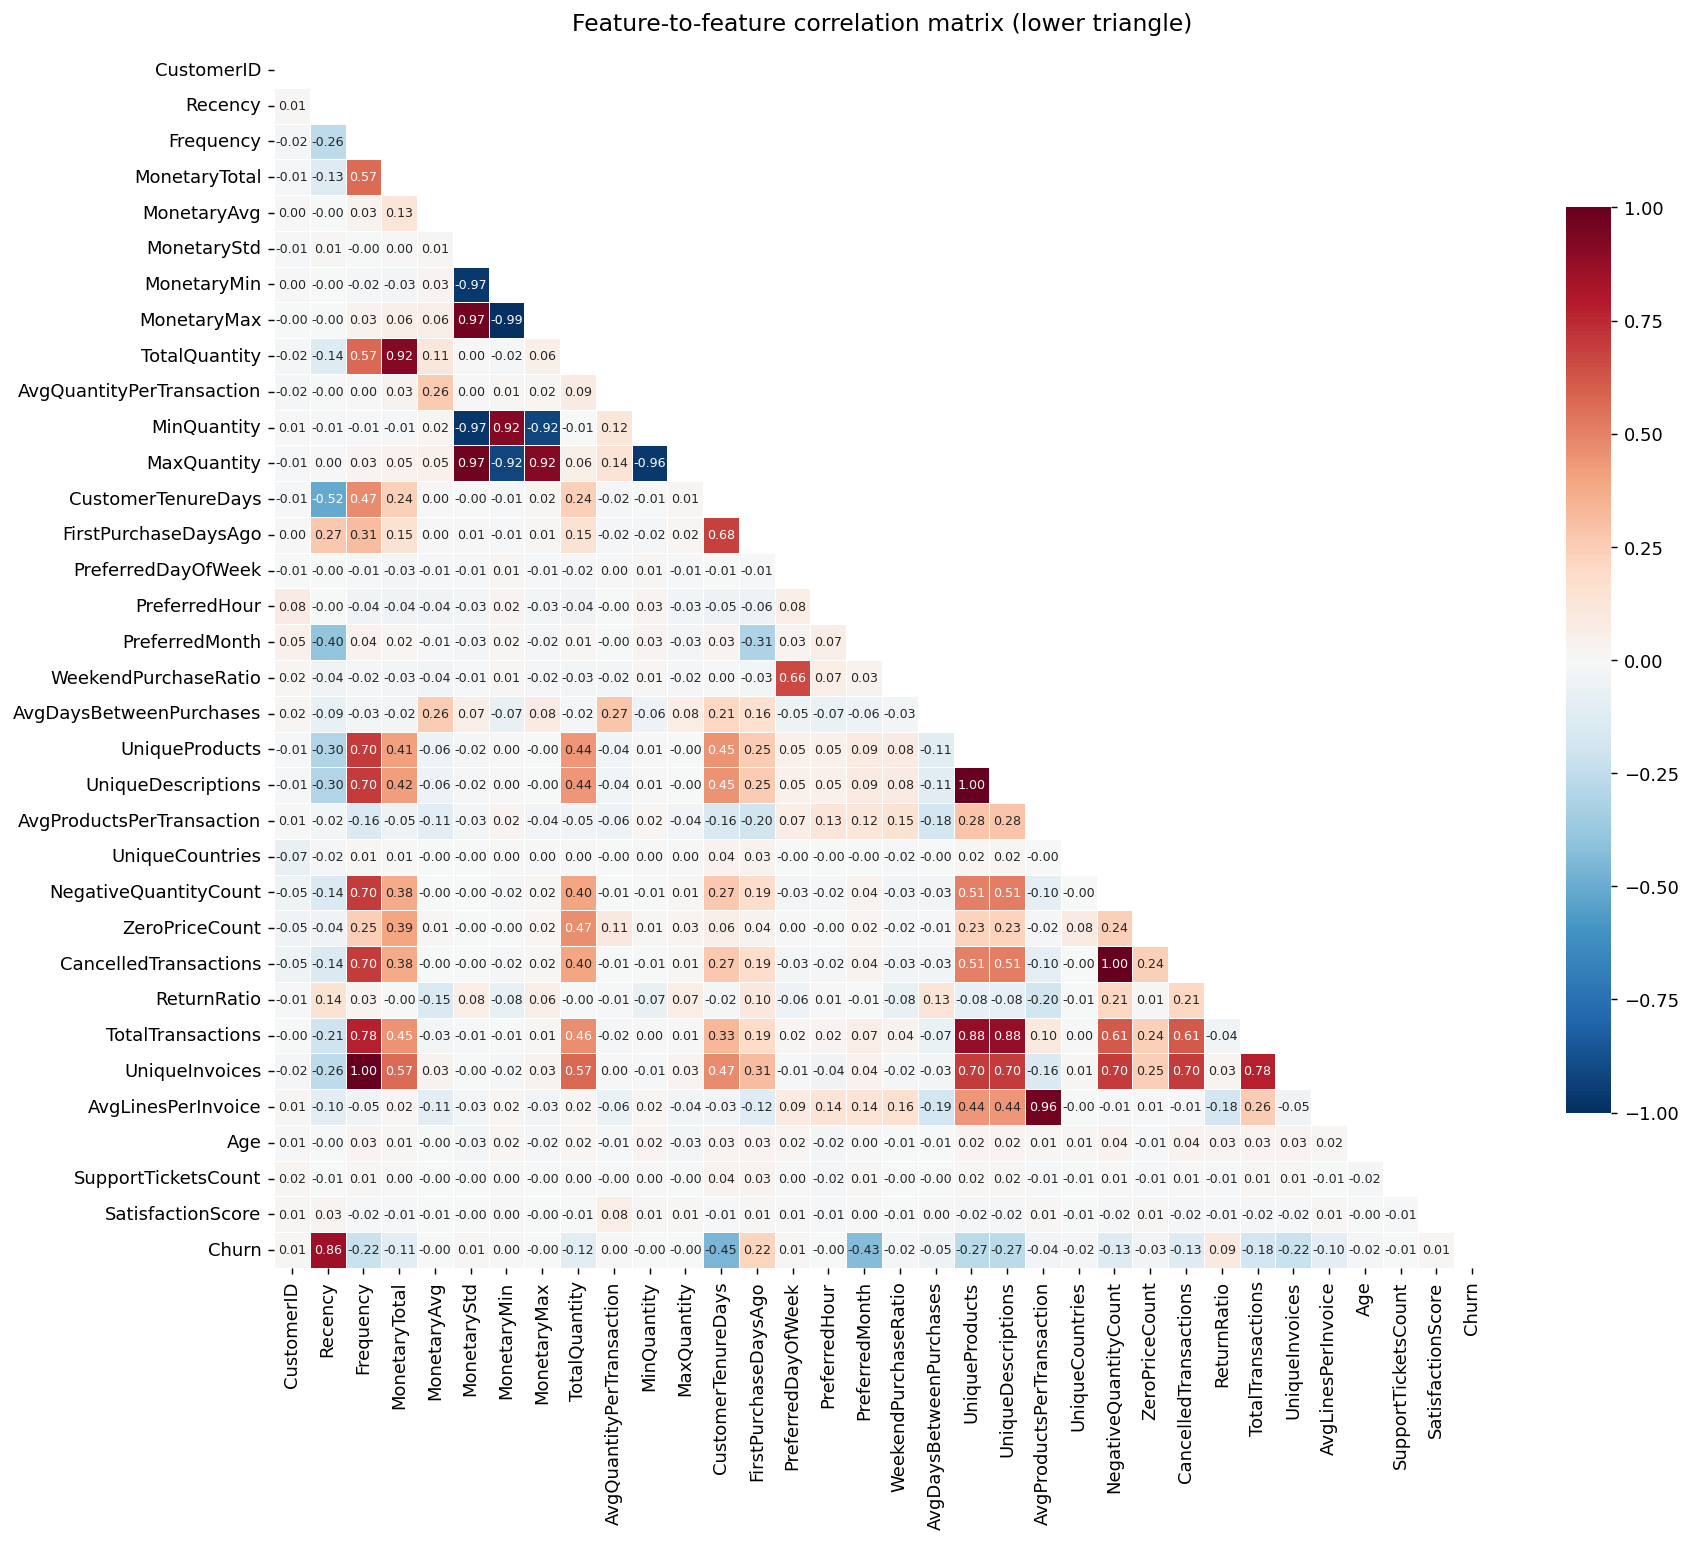


Highly correlated feature pairs (|r| > 0.7) — redundancy candidates:
  Recency                        ↔  Churn                           r=+0.859  → Consider dropping one
  Frequency                      ↔  TotalTransactions               r=+0.778  → Consider dropping one
  Frequency                      ↔  UniqueInvoices                  r=+1.000  → Consider dropping one
  MonetaryTotal                  ↔  TotalQuantity                   r=+0.922  → Consider dropping one
  MonetaryStd                    ↔  MonetaryMin                     r=-0.967  → Consider dropping one
  MonetaryStd                    ↔  MonetaryMax                     r=+0.966  → Consider dropping one
  MonetaryStd                    ↔  MinQuantity                     r=-0.974  → Consider dropping one
  MonetaryStd                    ↔  MaxQuantity                     r=+0.973  → Consider dropping one
  MonetaryMin                    ↔  MonetaryMax                     r=-0.994  → Consider dropping one
  MonetaryMi

In [15]:
# Full correlation matrix (what you already have)
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle masked

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.7},
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Feature-to-feature correlation matrix (lower triangle)', fontweight='500', pad=12)
plt.tight_layout()
plt.savefig('reports/eda_03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print highly correlated pairs (redundancy candidates)
print('\nHighly correlated feature pairs (|r| > 0.7) — redundancy candidates:')
print('='*60)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
            high_corr.append({'Feature A': f1, 'Feature B': f2, 'Correlation': round(val, 3)})
            print(f'  {f1:<30} ↔  {f2:<30}  r={val:+.3f}  → Consider dropping one')

if not high_corr:
    print('  None found above 0.7')

---
## 5. Distribution plots — numeric features by Churn

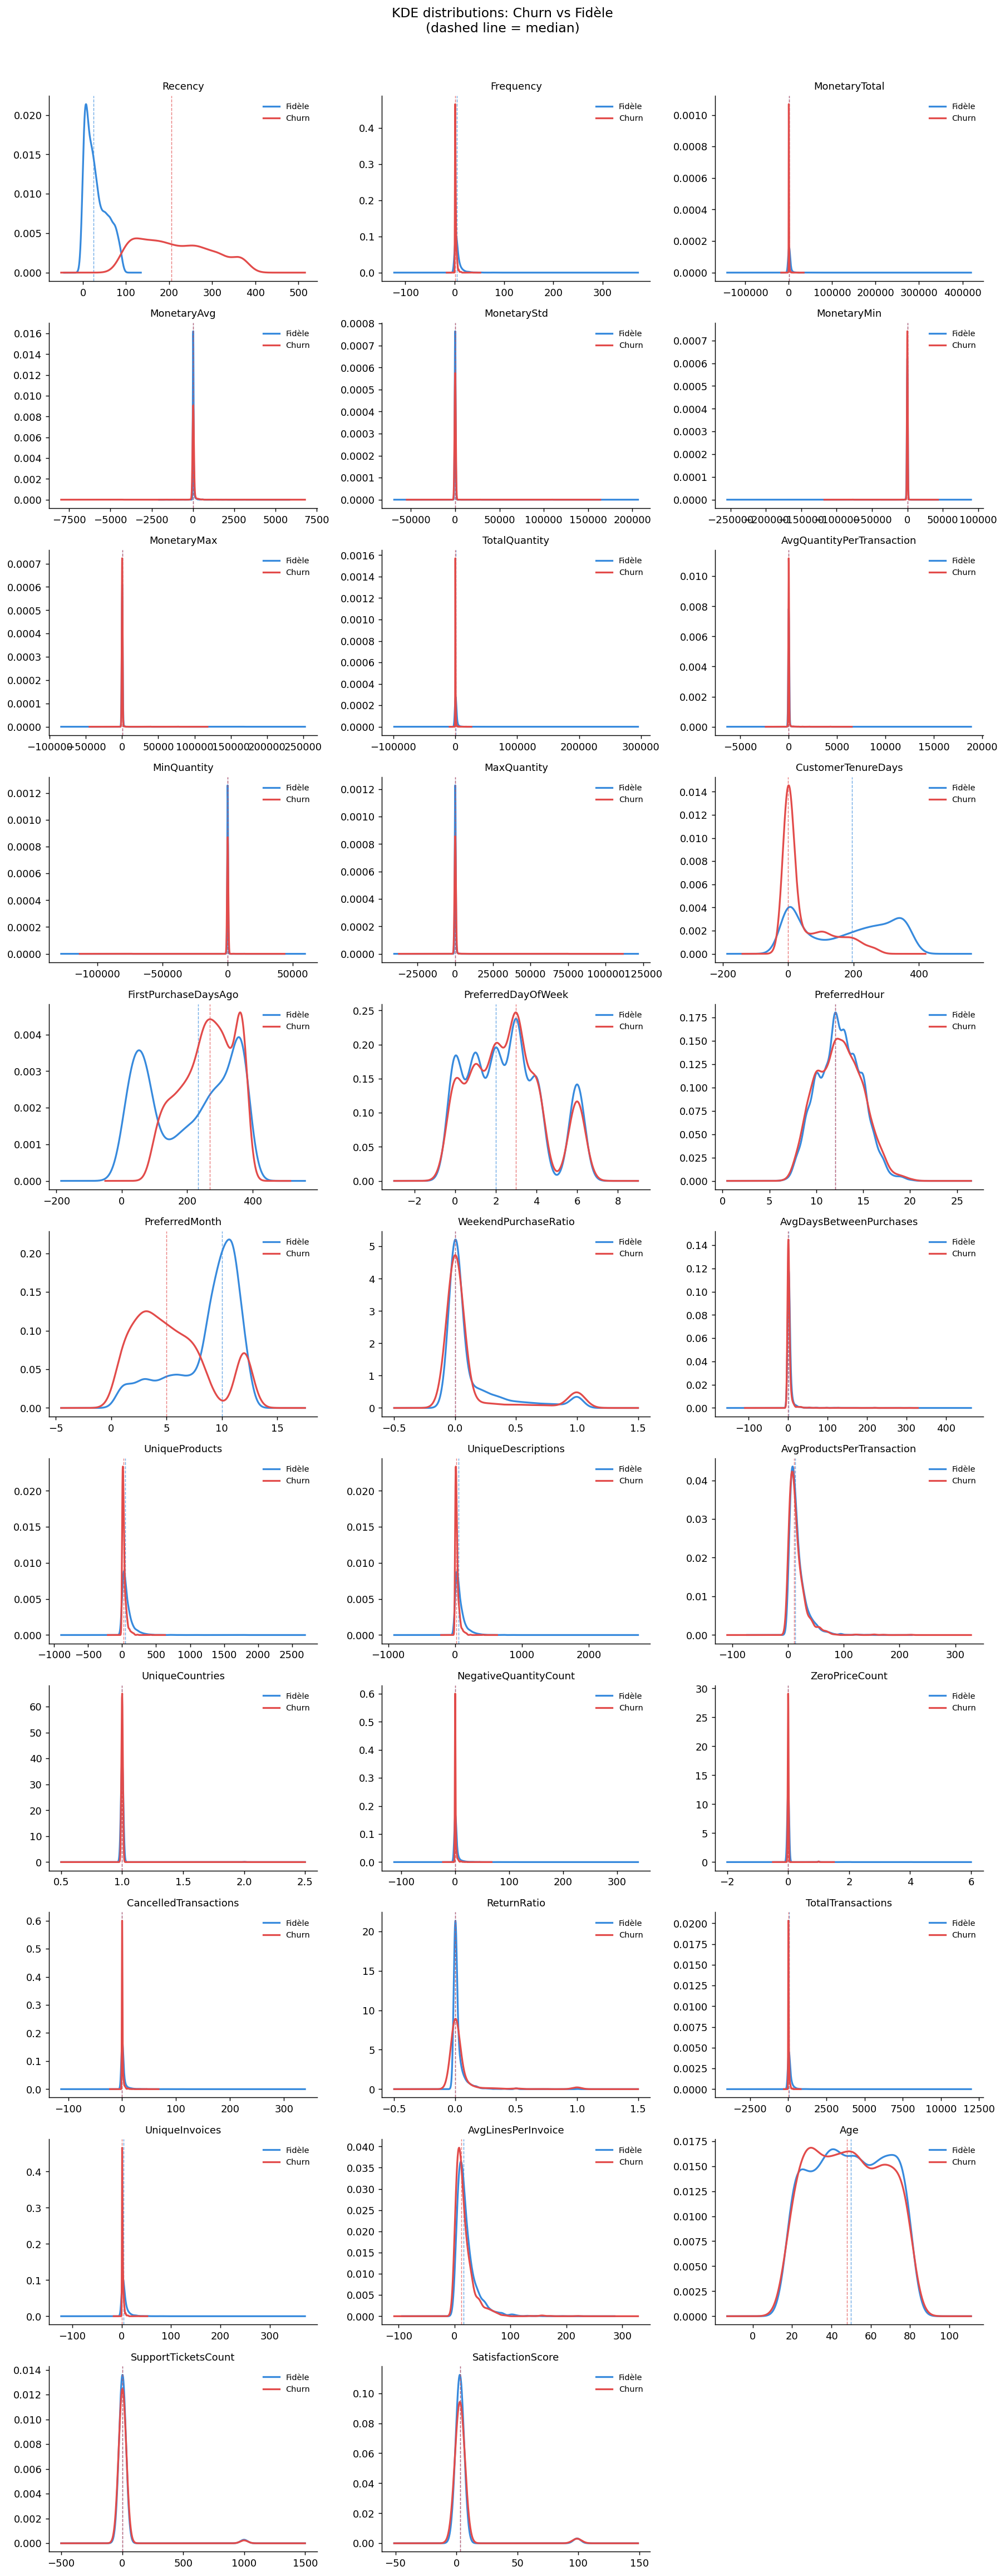

💡 Features where curves are well-separated = strong predictors
💡 Features where curves overlap completely = weak predictors


In [16]:
# KDE plots: for each numeric feature, overlay Churn=0 vs Churn=1
# This shows you which features SEPARATE the two classes visually

num_cols = [c for c in numeric_df.columns if c not in ['Churn','CustomerID']]
n_cols   = 3
n_rows   = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for churn_val, label, color in [(0,'Fidèle',C_LOYAL),(1,'Churn',C_CHURN)]:
        data = df[df['Churn']==churn_val][col].dropna()
        data.plot.kde(ax=ax, label=label, color=color, linewidth=1.8)
        ax.axvline(data.median(), color=color, linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_title(col, fontsize=10, fontweight='500')
    ax.set_ylabel('')
    ax.legend(fontsize=8, frameon=False)
    ax.set_xlabel('')

# Hide empty subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('KDE distributions: Churn vs Fidèle\n(dashed line = median)', 
             fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('reports/eda_04_kde_distributions.png', bbox_inches='tight')
plt.show()
print('💡 Features where curves are well-separated = strong predictors')
print('💡 Features where curves overlap completely = weak predictors')

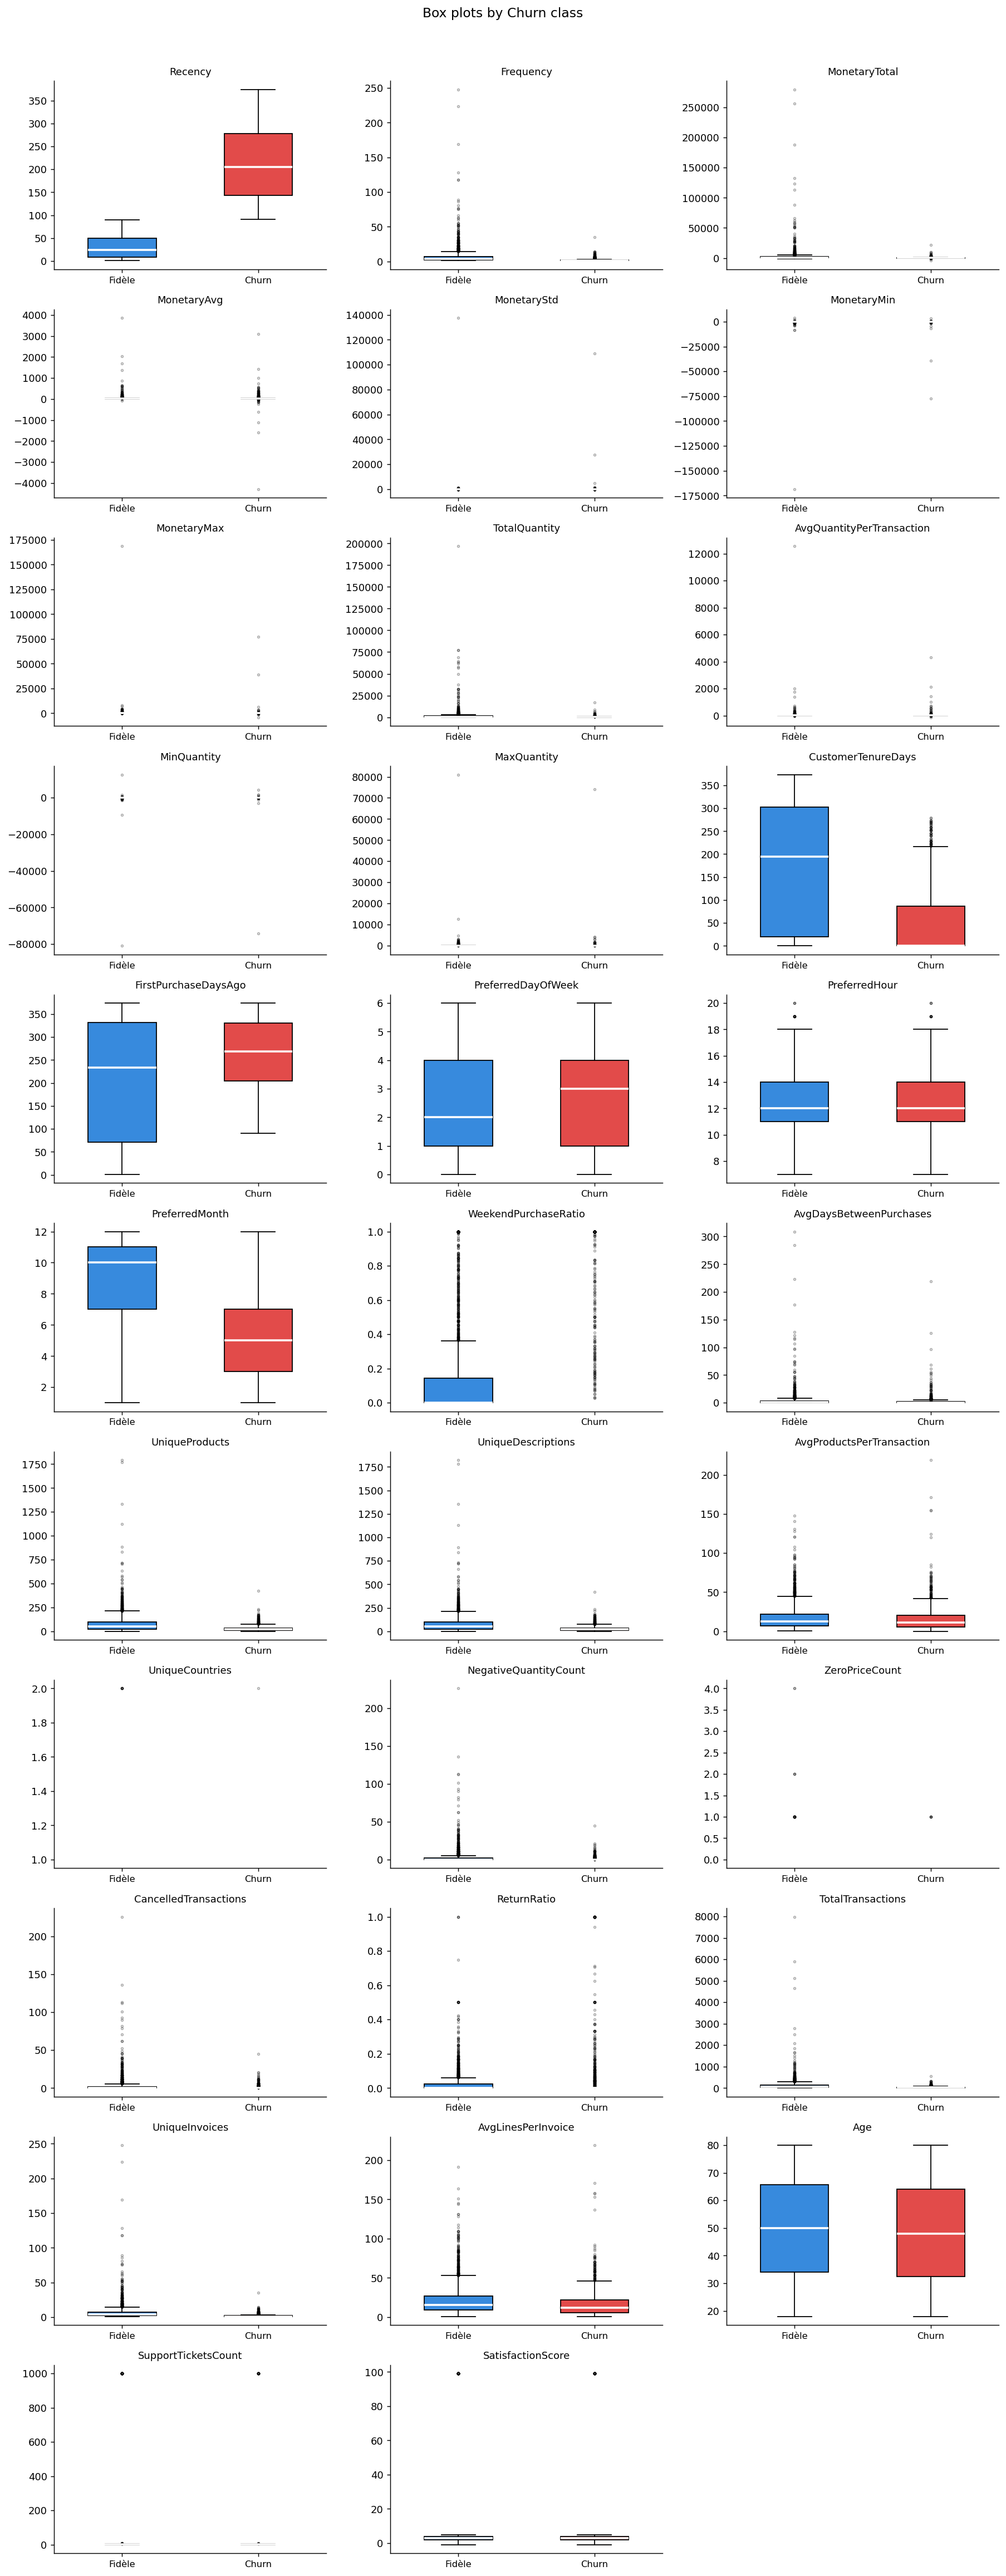

In [17]:
# Box plots — same info, different visual angle
# Good for spotting outliers and median shifts between classes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.2))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data_0 = df[df['Churn']==0][col].dropna()
    data_1 = df[df['Churn']==1][col].dropna()

    bp = ax.boxplot([data_0, data_1],
                    patch_artist=True,
                    widths=0.5,
                    medianprops={'color':'white','linewidth':2},
                    whiskerprops={'linewidth':1},
                    capprops={'linewidth':1},
                    flierprops={'marker':'o','markersize':2,'alpha':0.3})
    bp['boxes'][0].set_facecolor(C_LOYAL)
    bp['boxes'][1].set_facecolor(C_CHURN)
    ax.set_xticklabels(['Fidèle','Churn'], fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='500')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box plots by Churn class', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('reports/eda_05_boxplots.png', bbox_inches='tight')
plt.show()

---
## 6. Churn rate by category — categorical features

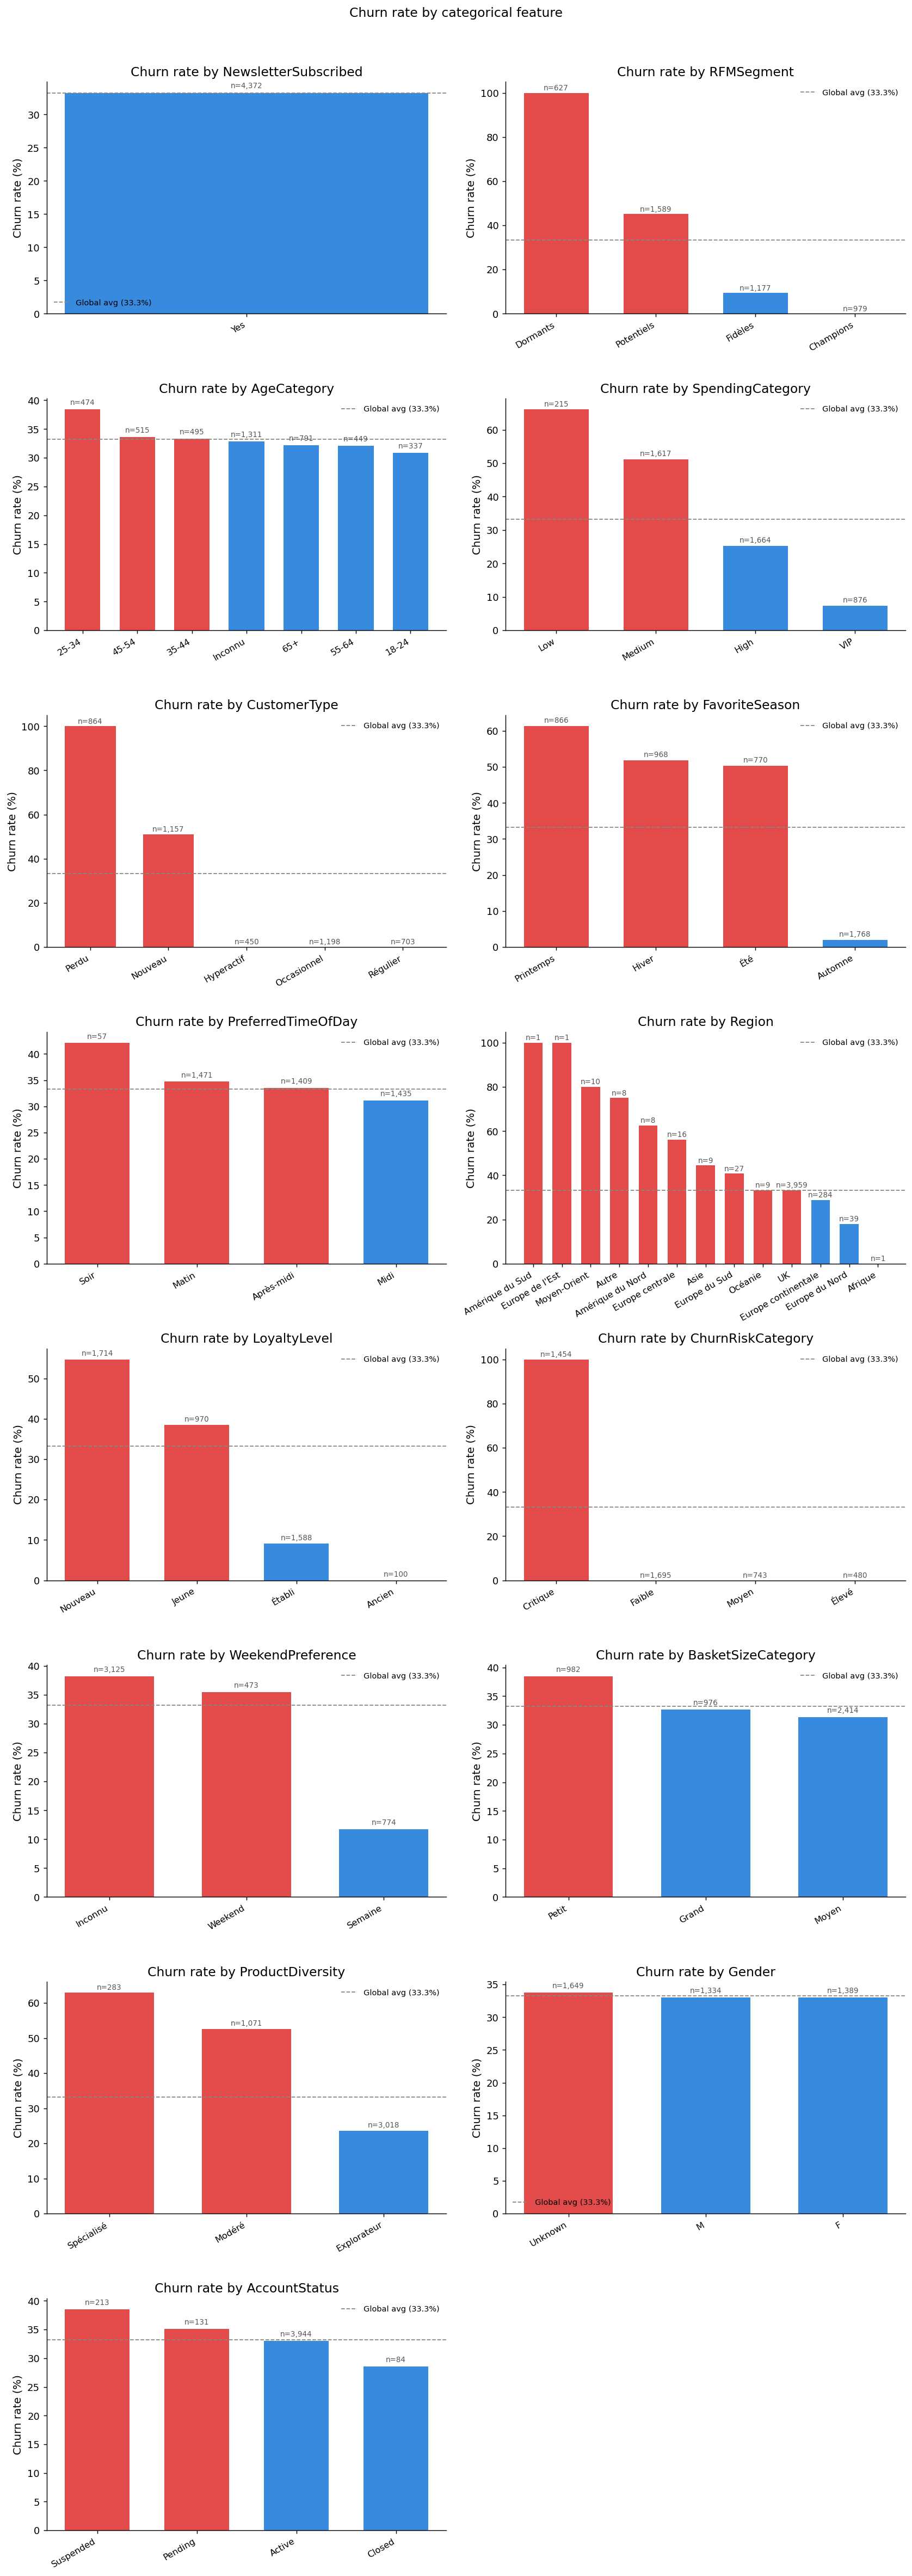

In [18]:
# For each categorical column: compute churn rate per category
# This shows which category VALUES are most associated with churn

cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Churn'] and df[c].nunique() <= 20]

if cat_cols:
    n_c  = min(2, len(cat_cols))
    n_r  = int(np.ceil(len(cat_cols) / n_c))
    fig, axes = plt.subplots(n_r, n_c, figsize=(13, n_r * 4.5))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_cols):
        ax   = axes[i]
        rate = (df.groupby(col)['Churn'].mean() * 100).sort_values(ascending=False)
        count= df[col].value_counts()

        bar_colors = [C_CHURN if v > df['Churn'].mean()*100 else C_LOYAL for v in rate.values]
        bars = ax.bar(range(len(rate)), rate.values, color=bar_colors, edgecolor='none', width=0.65)

        # Add count labels inside bars
        for j, (bar, cat) in enumerate(zip(bars, rate.index)):
            ax.text(j, bar.get_height()+0.5, f'n={count[cat]:,}',
                    ha='center', va='bottom', fontsize=7.5, color='#555')

        ax.axhline(df['Churn'].mean()*100, color=C_NEUTRAL, linestyle='--',
                   linewidth=1, label=f'Global avg ({df["Churn"].mean()*100:.1f}%)')
        ax.set_xticks(range(len(rate)))
        ax.set_xticklabels(rate.index, rotation=30, ha='right', fontsize=9)
        ax.set_ylabel('Churn rate (%)')
        ax.set_title(f'Churn rate by {col}', fontweight='500')
        ax.legend(fontsize=8, frameon=False)

    for j in range(len(cat_cols), len(axes)): axes[j].set_visible(False)

    plt.suptitle('Churn rate by categorical feature', fontsize=13, fontweight='500', y=1.01)
    plt.tight_layout()
    plt.savefig('reports/eda_06_churn_by_category.png', bbox_inches='tight')
    plt.show()
else:
    print('No low-cardinality categorical columns found.')

---
## 7. Missing values analysis

Columns with missing values: 2 / 52

                         Count  Percentage (%)
Age                       1311           29.99
AvgDaysBetweenPurchases     79            1.81


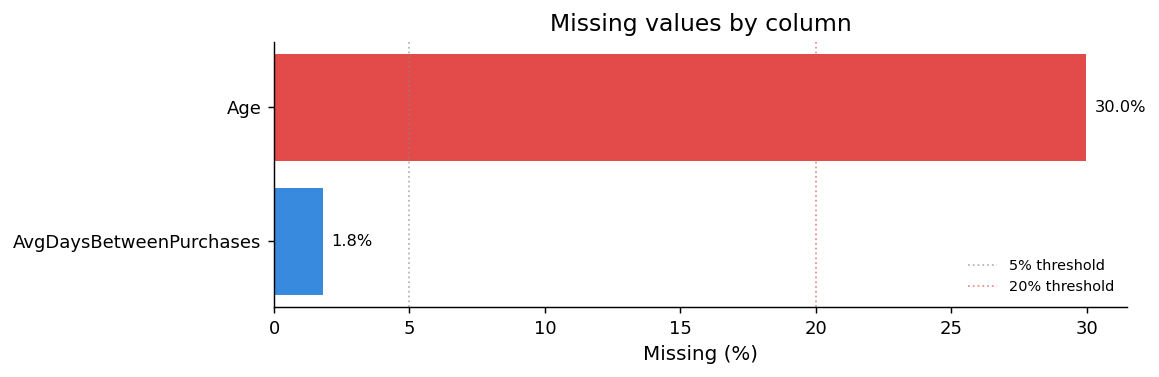


Is being missing correlated with Churn?
(If yes, the missingness itself is informative — add IsMissing flag)
  Age                            corr=-0.0053
  AvgDaysBetweenPurchases        corr=+0.1339  ← add IsMissing flag!


In [19]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

print(f'Columns with missing values: {len(missing)} / {df.shape[1]}')
print()
summary = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(summary.to_string())

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing)*0.4)))
    colors_m = [C_CHURN if p > 20 else (C_NEUTRAL if p > 5 else C_LOYAL) for p in missing_pct.values]
    ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color=colors_m[::-1], edgecolor='none')

    for i, (col, pct) in enumerate(zip(missing_pct.index[::-1], missing_pct.values[::-1])):
        ax.text(pct+0.3, i, f'{pct:.1f}%', va='center', fontsize=9)

    ax.axvline(5,  color=C_NEUTRAL, linestyle=':', linewidth=1, alpha=0.6, label='5% threshold')
    ax.axvline(20, color=C_CHURN,   linestyle=':', linewidth=1, alpha=0.6, label='20% threshold')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing values by column', fontweight='500')
    ax.legend(fontsize=8, frameon=False)
    plt.tight_layout()
    plt.savefig('reports/eda_07_missing_values.png', bbox_inches='tight')
    plt.show()

    # Is missingness correlated with Churn?
    print('\nIs being missing correlated with Churn?')
    print('(If yes, the missingness itself is informative — add IsMissing flag)')
    print('='*55)
    for col in missing.index:
        is_missing = df[col].isnull().astype(int)
        corr_val   = is_missing.corr(df['Churn'])
        flag = '  ← add IsMissing flag!' if abs(corr_val) > 0.05 else ''
        print(f'  {col:<30} corr={corr_val:+.4f}{flag}')
else:
    print('✅ No missing values found in raw data.')

---
## 8. Outlier detection — IQR method

In [20]:
# IQR-based outlier detection for each numeric column
print('Outlier analysis (IQR method — values beyond Q1-1.5×IQR or Q3+1.5×IQR):')
print('='*65)

outlier_summary = []
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    skew  = df[col].skew()
    outlier_summary.append({'Feature': col, 'N outliers': n_out,
                            '% outliers': round(pct,2), 'Skewness': round(skew,3),
                            'Log-transform?': '✅ Yes' if abs(skew) > 1 else 'No'})

out_df = pd.DataFrame(outlier_summary).sort_values('% outliers', ascending=False)
out_df.style.background_gradient(cmap='Reds', subset=['% outliers'])

Outlier analysis (IQR method — values beyond Q1-1.5×IQR or Q3+1.5×IQR):


,Feature,N outliers,% outliers,Skewness,Log-transform?
16,WeekendPurchaseRatio,833,19.050000,2.241000,✅ Yes
22,NegativeQuantityCount,783,17.910000,13.035000,✅ Yes
24,CancelledTransactions,783,17.910000,13.035000,✅ Yes
9,MinQuantity,771,17.630000,-45.131000,✅ Yes
25,ReturnRatio,623,14.250000,6.756000,✅ Yes
5,MonetaryMin,519,11.870000,-50.904000,✅ Yes
3,MonetaryAvg,505,11.550000,2.442000,✅ Yes
6,MonetaryMax,501,11.460000,50.547000,✅ Yes
4,MonetaryStd,482,11.020000,46.097000,✅ Yes
2,MonetaryTotal,423,9.680000,21.705000,✅ Yes


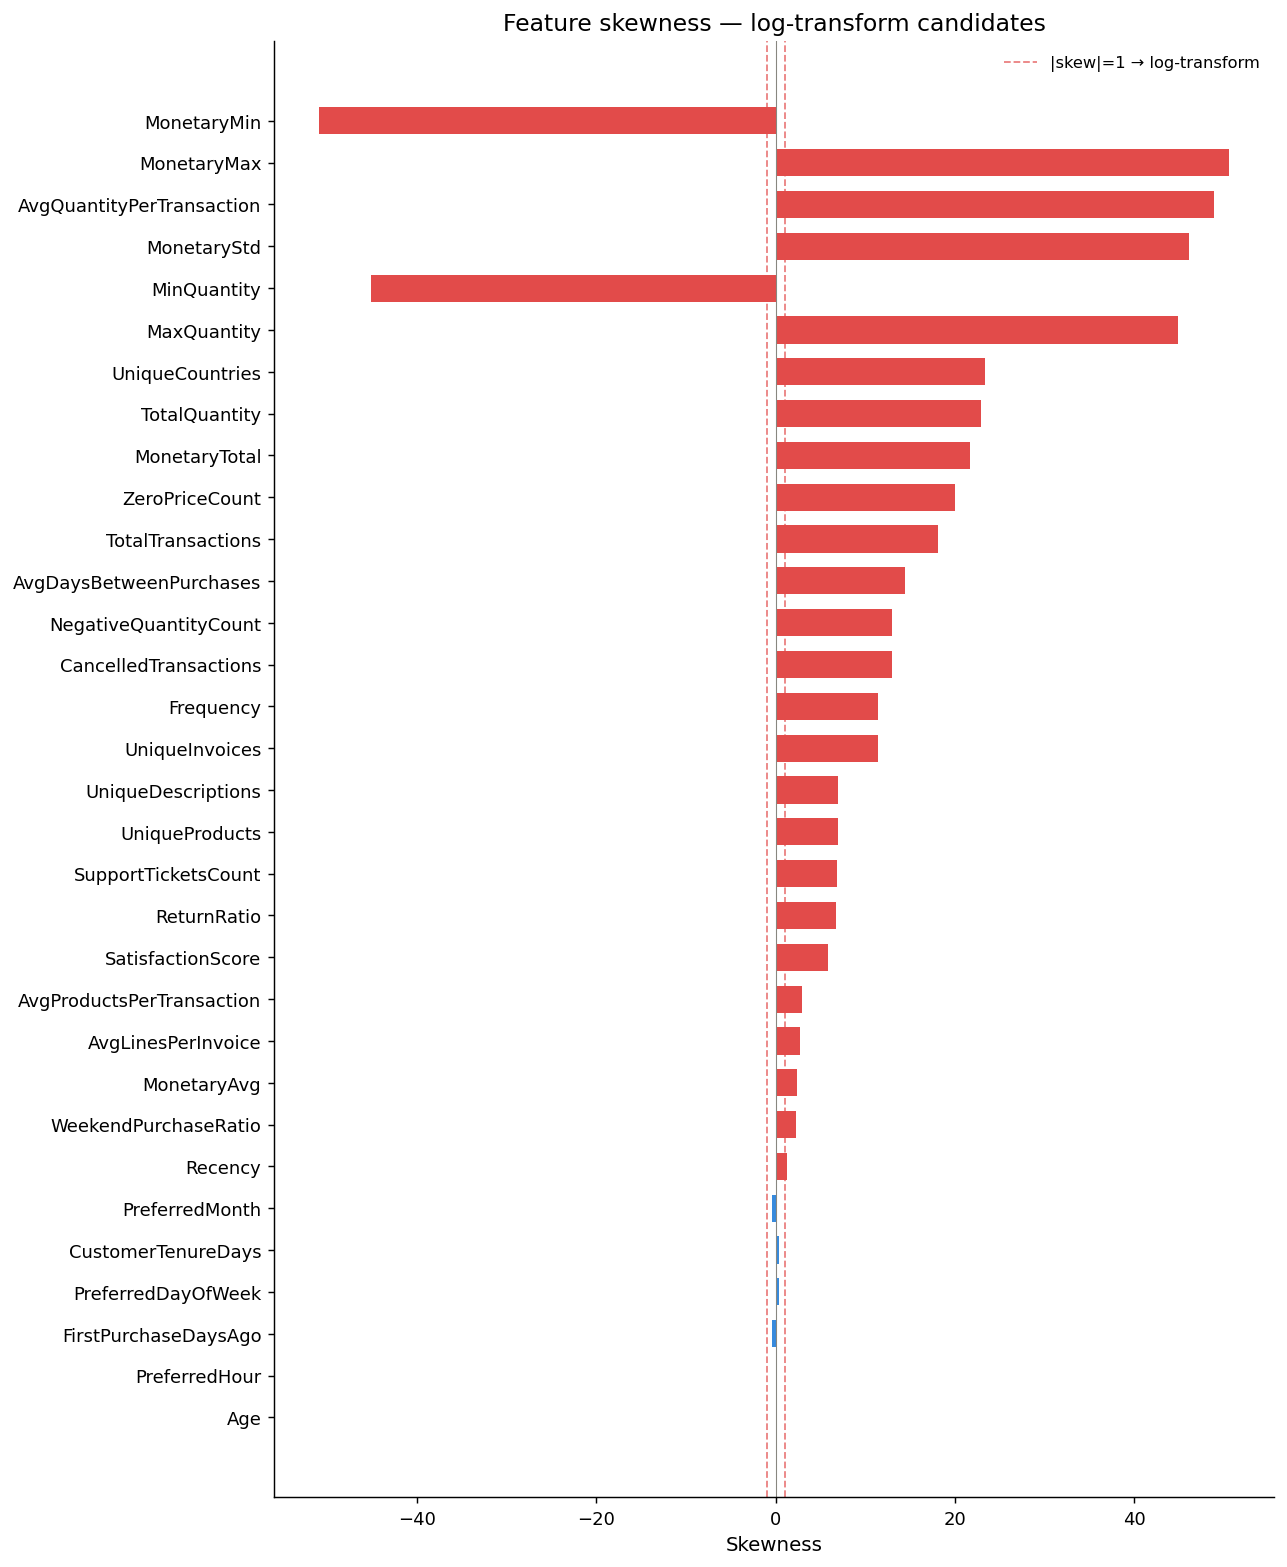


📋 Log-transform candidates (|skew| > 1): ['MonetaryMin', 'MonetaryMax', 'AvgQuantityPerTransaction', 'MonetaryStd', 'MinQuantity', 'MaxQuantity', 'UniqueCountries', 'TotalQuantity', 'MonetaryTotal', 'ZeroPriceCount', 'TotalTransactions', 'AvgDaysBetweenPurchases', 'NegativeQuantityCount', 'CancelledTransactions', 'Frequency', 'UniqueInvoices', 'UniqueDescriptions', 'UniqueProducts', 'SupportTicketsCount', 'ReturnRatio', 'SatisfactionScore', 'AvgProductsPerTransaction', 'AvgLinesPerInvoice', 'MonetaryAvg', 'WeekendPurchaseRatio', 'Recency']


In [21]:
# Visualize skewness — helps decide which columns need log transformation
skews = df[num_cols].skew().sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(skews)*0.38)))
colors_s = [C_CHURN if abs(v) > 1 else (C_NEUTRAL if abs(v) > 0.5 else C_LOYAL) for v in skews.values]
ax.barh(skews.index[::-1], skews.values[::-1], color=colors_s[::-1], edgecolor='none', height=0.65)
ax.axvline( 1, color=C_CHURN,   linestyle='--', linewidth=1, alpha=0.7, label='|skew|=1 → log-transform')
ax.axvline(-1, color=C_CHURN,   linestyle='--', linewidth=1, alpha=0.7)
ax.axvline( 0, color=C_NEUTRAL, linestyle='-',  linewidth=0.6)
ax.set_xlabel('Skewness')
ax.set_title('Feature skewness — log-transform candidates', fontweight='500')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('reports/eda_08_skewness.png', bbox_inches='tight')
plt.show()

log_candidates = skews[abs(skews) > 1].index.tolist()
print(f'\n📋 Log-transform candidates (|skew| > 1): {log_candidates}')

---
## 9. Temporal patterns — RegistrationDate

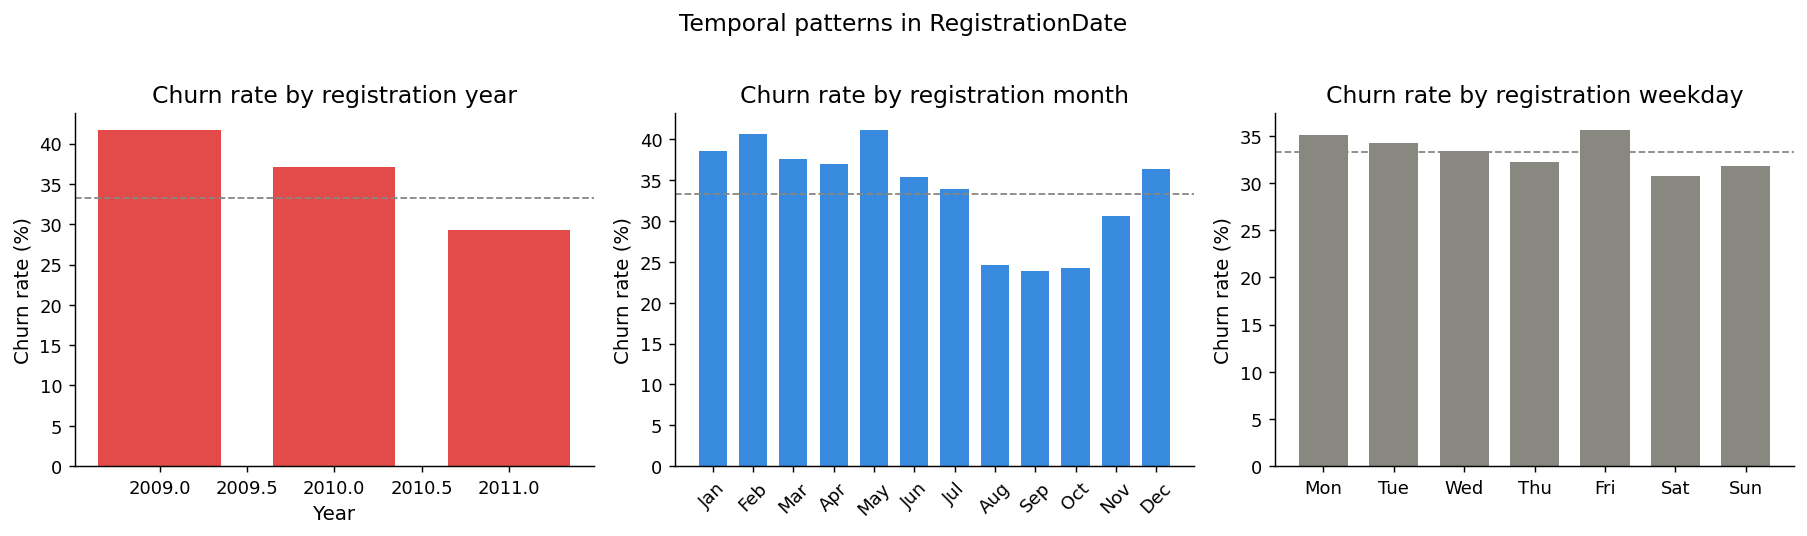

In [22]:
if 'RegistrationDate' in df.columns:
    df['RegistrationDate_parsed'] = pd.to_datetime(
        df['RegistrationDate'], dayfirst=True, errors='coerce'
    )
    df['RegYear']    = df['RegistrationDate_parsed'].dt.year
    df['RegMonth']   = df['RegistrationDate_parsed'].dt.month
    df['RegWeekday'] = df['RegistrationDate_parsed'].dt.weekday

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Churn rate by registration year
    year_churn = df.groupby('RegYear')['Churn'].mean() * 100
    axes[0].bar(year_churn.index, year_churn.values, color=C_CHURN, edgecolor='none', width=0.7)
    axes[0].axhline(df['Churn'].mean()*100, color=C_NEUTRAL, linestyle='--', linewidth=1)
    axes[0].set_title('Churn rate by registration year', fontweight='500')
    axes[0].set_ylabel('Churn rate (%)')
    axes[0].set_xlabel('Year')

    # Churn rate by registration month
    month_churn = df.groupby('RegMonth')['Churn'].mean() * 100
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    axes[1].bar(range(len(month_churn)), month_churn.values, color=C_LOYAL, edgecolor='none', width=0.7)
    axes[1].axhline(df['Churn'].mean()*100, color=C_NEUTRAL, linestyle='--', linewidth=1)
    axes[1].set_xticks(range(len(month_churn)))
    axes[1].set_xticklabels([month_names[m-1] for m in month_churn.index], rotation=45)
    axes[1].set_title('Churn rate by registration month', fontweight='500')
    axes[1].set_ylabel('Churn rate (%)')

    # Churn rate by weekday
    day_churn  = df.groupby('RegWeekday')['Churn'].mean() * 100
    day_names  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    axes[2].bar(range(len(day_churn)), day_churn.values, color=C_NEUTRAL, edgecolor='none', width=0.7)
    axes[2].axhline(df['Churn'].mean()*100, color=C_NEUTRAL, linestyle='--', linewidth=1)
    axes[2].set_xticks(range(len(day_churn)))
    axes[2].set_xticklabels([day_names[d] for d in day_churn.index])
    axes[2].set_title('Churn rate by registration weekday', fontweight='500')
    axes[2].set_ylabel('Churn rate (%)')

    plt.suptitle('Temporal patterns in RegistrationDate', fontsize=13, fontweight='500', y=1.02)
    plt.tight_layout()
    plt.savefig('reports/eda_09_temporal_patterns.png', bbox_inches='tight')
    plt.show()

    df = df.drop(columns=['RegistrationDate_parsed','RegYear','RegMonth','RegWeekday'])
else:
    print('RegistrationDate not found in dataset.')

---
## 10. Country churn rates (top 20)

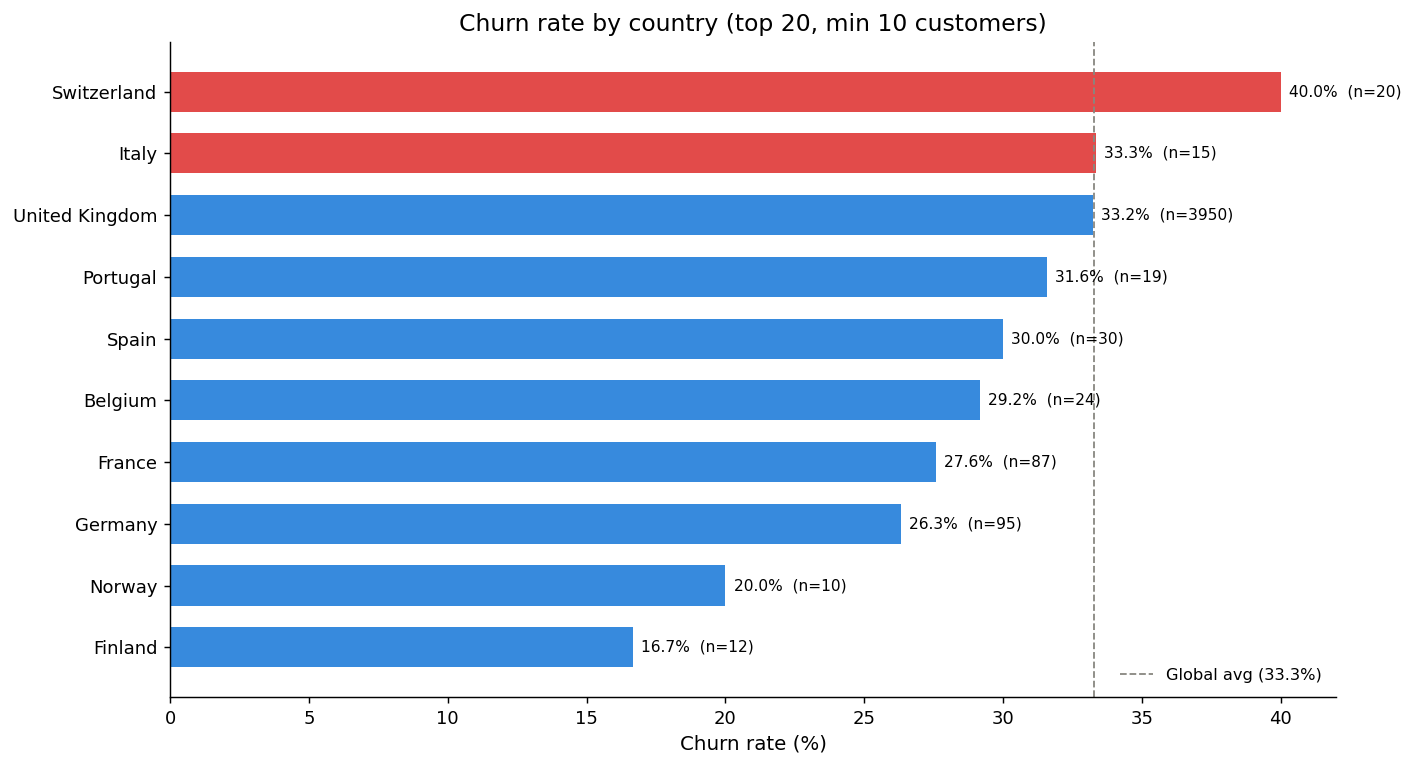


📋 Unique countries: 37
   → Too many for OHE → use Target Encoding in preprocessing


In [23]:
if 'Country' in df.columns:
    country_stats = df.groupby('Country').agg(
        ChurnRate=('Churn','mean'),
        Count=('Churn','count')
    ).reset_index()
    country_stats['ChurnRate'] *= 100
    country_stats = country_stats[country_stats['Count'] >= 10]  # min 10 customers
    country_stats = country_stats.sort_values('ChurnRate', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(11, 6))
    global_rate = df['Churn'].mean() * 100
    colors_c = [C_CHURN if r > global_rate else C_LOYAL for r in country_stats['ChurnRate']]

    bars = ax.barh(country_stats['Country'][::-1], country_stats['ChurnRate'][::-1],
                   color=colors_c[::-1], edgecolor='none', height=0.65)

    for i, (bar, row) in enumerate(zip(bars, country_stats.iloc[::-1].itertuples())):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                f'{row.ChurnRate:.1f}%  (n={row.Count})',
                va='center', fontsize=8.5)

    ax.axvline(global_rate, color=C_NEUTRAL, linestyle='--', linewidth=1,
               label=f'Global avg ({global_rate:.1f}%)')
    ax.set_xlabel('Churn rate (%)')
    ax.set_title('Churn rate by country (top 20, min 10 customers)', fontweight='500')
    ax.legend(fontsize=9, frameon=False)
    plt.tight_layout()
    plt.savefig('reports/eda_10_country_churn.png', bbox_inches='tight')
    plt.show()

    print(f'\n📋 Unique countries: {df["Country"].nunique()}')
    print(f'   → Too many for OHE → use Target Encoding in preprocessing')
else:
    print('Country column not found.')

---
## 11. Key findings summary

In [24]:
print('=' * 65)
print('  EDA KEY FINDINGS SUMMARY')
print('=' * 65)

print(f"""
1. CLASS IMBALANCE
   Churn rate = {df['Churn'].mean():.1%}
   → Use stratified split + SMOTE inside CV folds

2. LEAKY COLUMNS (drop before training)
   Detected via correlation vector with Churn:
   {[c for c in churn_corr[abs(churn_corr)>0.5].index.tolist()]}
   + ChurnRiskCategory, RFMSegment, LoyaltyLevel, CustomerType
     (derived from Churn — domain knowledge, not just correlation)

3. REDUNDANT COLUMNS (high inter-feature correlation)
   {[f"{r['Feature A']} ↔ {r['Feature B']} ({r['Correlation']})" for r in high_corr[:5]]}

4. LOG-TRANSFORM CANDIDATES (|skew| > 1)
   {log_candidates}

5. COUNTRY ENCODING
   {df['Country'].nunique() if 'Country' in df.columns else 'N/A'} unique countries → Target Encoding (not OHE)

6. DATE PARSING
   RegistrationDate: 3 mixed formats → extract RegYear/Month/Day/Weekday

7. IP ADDRESS
   LastLoginIP → extract IsPrivateIP + IPClass before dropping
""")
print('=' * 65)

  EDA KEY FINDINGS SUMMARY

1. CLASS IMBALANCE
   Churn rate = 33.3%
   → Use stratified split + SMOTE inside CV folds

2. LEAKY COLUMNS (drop before training)
   Detected via correlation vector with Churn:
   ['Recency']
   + ChurnRiskCategory, RFMSegment, LoyaltyLevel, CustomerType
     (derived from Churn — domain knowledge, not just correlation)

3. REDUNDANT COLUMNS (high inter-feature correlation)
   ['Recency ↔ Churn (0.859)', 'Frequency ↔ TotalTransactions (0.778)', 'Frequency ↔ UniqueInvoices (1.0)', 'MonetaryTotal ↔ TotalQuantity (0.922)', 'MonetaryStd ↔ MonetaryMin (-0.967)']

4. LOG-TRANSFORM CANDIDATES (|skew| > 1)
   ['MonetaryMin', 'MonetaryMax', 'AvgQuantityPerTransaction', 'MonetaryStd', 'MinQuantity', 'MaxQuantity', 'UniqueCountries', 'TotalQuantity', 'MonetaryTotal', 'ZeroPriceCount', 'TotalTransactions', 'AvgDaysBetweenPurchases', 'NegativeQuantityCount', 'CancelledTransactions', 'Frequency', 'UniqueInvoices', 'UniqueDescriptions', 'UniqueProducts', 'SupportTicketsC